Importing required libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns   

Phase 1 : Data Foundation

In [2]:
original_data = pd.read_csv(r"C:\Users\chaka\Preethu\My_Git_Repo\Final Project_Rideflow\Datasets\rideflow_datasets.csv")
original_data.head()

,ride_id,timestamp,pickup_zone,drop_zone,pickup_lat,pickup_long,drop_lat,drop_long,driver_id,customer_id,...,surge_multiplier,driver_rating,customer_rating,estimated_eta_min,actual_eta_min,ride_status,traffic_level,weather,driver_active,feedback_text
0,95.247911,2025-01-02 01:30:00,Anna Nagar,Adyar,12.880239,80.148410,13.028939,80.163941,1842.701958,6072.494896,...,1.001779,4.350624,4.037232,11.778023,18.304775,cancelled,low,clear,-0.036560,Driver was polite
1,439.187632,2025-01-05 12:45:00,T Nagar,Tambaram,13.092441,80.165458,13.142711,80.149376,1186.296422,5942.228896,...,1.193147,4.524196,3.324278,4.430894,13.343961,completed,low,cloudy,0.988999,Driver cancelled suddenly
2,876.685389,2025-01-09 23:00:00,Anna Nagar,Tambaram,12.817965,80.161839,12.943527,80.166040,1297.199801,5829.181415,...,2.008478,4.054085,4.979153,19.202891,12.039878,completed,low,rain,0.005750,Driver cancelled suddenly
3,275.337197,2025-01-03 19:30:00,T Nagar,Velachery,13.125103,80.143306,13.209127,80.126008,1765.474261,5429.619496,...,1.218528,3.689937,3.099466,18.711931,7.535792,completed,low,clear,1.023604,Good experience
4,106.743950,2025-01-02 02:30:00,Tambaram,Tambaram,13.143513,80.302596,13.078330,80.189672,1565.653849,5079.081677,...,1.497370,3.545512,3.073704,10.786351,12.104096,completed,high,cloudy,1.016716,Vehicle was not clean


In [3]:
original_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ride_id            50000 non-null  float64
 1   timestamp          50000 non-null  object 
 2   pickup_zone        50000 non-null  object 
 3   drop_zone          50000 non-null  object 
 4   pickup_lat         50000 non-null  float64
 5   pickup_long        50000 non-null  float64
 6   drop_lat           50000 non-null  float64
 7   drop_long          50000 non-null  float64
 8   driver_id          50000 non-null  float64
 9   customer_id        50000 non-null  float64
 10  fare_price         50000 non-null  float64
 11  surge_multiplier   50000 non-null  float64
 12  driver_rating      50000 non-null  float64
 13  customer_rating    50000 non-null  float64
 14  estimated_eta_min  50000 non-null  float64
 15  actual_eta_min     50000 non-null  float64
 16  ride_status        500

In [4]:
#null values in the dataset 
print(original_data.isnull().sum())
# duplicate values in the dataset
print(original_data.duplicated().sum())


ride_id              0
timestamp            0
pickup_zone          0
drop_zone            0
pickup_lat           0
pickup_long          0
drop_lat             0
drop_long            0
driver_id            0
customer_id          0
fare_price           0
surge_multiplier     0
driver_rating        0
customer_rating      0
estimated_eta_min    0
actual_eta_min       0
ride_status          0
traffic_level        0
weather              0
driver_active        0
feedback_text        0
dtype: int64
0


In [5]:
#fix data types
original_data['timestamp'] = pd.to_datetime(original_data['timestamp'])
original_data['ride_id'] = original_data['ride_id'].astype(int)
original_data['driver_id'] = original_data['driver_id'].astype(int)
original_data['customer_id'] = original_data['customer_id'].astype(int)
original_data['driver_active'] = original_data['driver_active'].astype(int)


In [6]:
#timestamp to date and time
original_data['hour'] = original_data['timestamp'].dt.hour
original_data['day_of_week'] = original_data['timestamp'].dt.dayofweek
original_data['is_weekend'] = original_data['day_of_week'].isin([5,6]).astype(int)

Simulation of few columns for more data

In [7]:
#available drivers per pickup zone and hour
original_data['available_drivers'] = original_data.groupby(['pickup_zone','hour'])['driver_id']\
                           .transform('nunique') + np.random.randint(-3,3,len(original_data))

In [ ]:
#distance in km
from geopy.distance import geodesic

original_data['distance_km'] = original_data.apply(lambda row:
    geodesic((row['pickup_lat'], row['pickup_long']),
                 (row['drop_lat'], row['drop_long'])).km, axis=1)

In [9]:
#cancellation risk score
original_data['cancellation_risk'] = (
    0.3 * original_data['estimated_eta_min'] +
    0.3 * original_data['surge_multiplier'] +
    0.2 * (5 - original_data['driver_rating']) +
    0.2 * np.random.rand(len(original_data))
)

In [10]:
#peak hour indicator
original_data['is_peak_hour'] = original_data['hour'].isin([7,8,9,16,17,18]).astype(int)

In [11]:
#eta_diff = actual_eta_min - estimated_eta_min
original_data['eta_diff'] = original_data['actual_eta_min'] - original_data['estimated_eta_min']

#negative values in dataset

In [12]:
#Resetting index for ride_id sincethere were negative values in the dataset which is unappropriate for a ride_id and also to ensure that ride_id is unique and sequential.
original_data = original_data.reset_index(drop=True)
original_data['ride_id'] = original_data.index + 1

In [13]:
numerical_columns = original_data.select_dtypes(include=['number']).columns.tolist()
print(numerical_columns)

['ride_id', 'pickup_lat', 'pickup_long', 'drop_lat', 'drop_long', 'driver_id', 'customer_id', 'fare_price', 'surge_multiplier', 'driver_rating', 'customer_rating', 'estimated_eta_min', 'actual_eta_min', 'driver_active', 'hour', 'day_of_week', 'is_weekend', 'available_drivers', 'distance_km', 'cancellation_risk', 'is_peak_hour', 'eta_diff']


In [14]:
# Count negatives in each column
negative_counts = (original_data[numerical_columns] < 0).sum()

print(negative_counts[negative_counts > 0])

eta_diff    18355
dtype: int64


ETA diff can have negative values - common and does not affect the model prediction

Dropping columns - simulated will be used

In [15]:
#drop timestamp
original_data = original_data.drop(columns=['timestamp'])

In [16]:
#dropping lat and long columns since we have distance_km which is more relevant for our analysis
original_data = original_data.drop(columns=['pickup_lat', 'pickup_long', 'drop_lat', 'drop_long'])

In [17]:
#target column creation - Demand prediction
original_data['ride_count'] = original_data.groupby(['pickup_zone','hour'])['ride_id'].transform('count')

In [18]:
original_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 25 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ride_id            50000 non-null  int64  
 1   pickup_zone        50000 non-null  object 
 2   drop_zone          50000 non-null  object 
 3   driver_id          50000 non-null  int64  
 4   customer_id        50000 non-null  int64  
 5   fare_price         50000 non-null  float64
 6   surge_multiplier   50000 non-null  float64
 7   driver_rating      50000 non-null  float64
 8   customer_rating    50000 non-null  float64
 9   estimated_eta_min  50000 non-null  float64
 10  actual_eta_min     50000 non-null  float64
 11  ride_status        50000 non-null  object 
 12  traffic_level      50000 non-null  object 
 13  weather            50000 non-null  object 
 14  driver_active      50000 non-null  int64  
 15  feedback_text      50000 non-null  object 
 16  hour               500

In [19]:
#save the cleaned dataset for future use
original_data.to_csv(r"C:\Users\chaka\Preethu\My_Git_Repo\Final Project_Rideflow\Datasets\cleaned_rideflow_datasets.csv", index=False)

In [20]:
#encoding target variable
original_data['ride_status'] = original_data['ride_status'].map({
    'completed': 0,
    'cancelled': 1
})

Pending: Encoding for features - will be done after EDA 
feature Columns: pickup_zone, drop_zone, traffic_level, weather
feedback_text - not needed for ML building

EDA

In [21]:
targets = ['ride_count', 'available_drivers', 'surge_multiplier', 'ride_status']

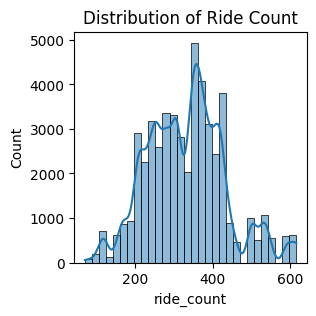

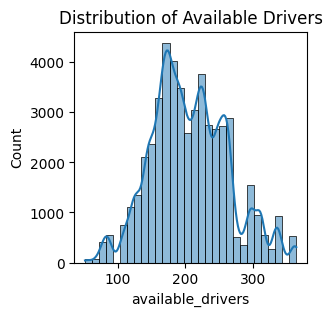

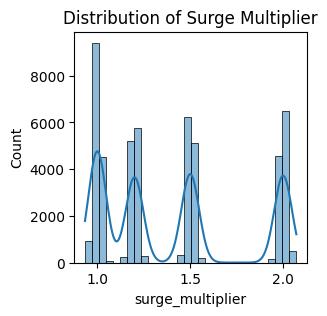

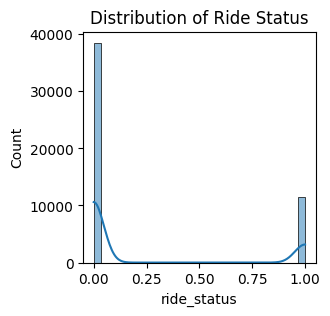

In [22]:
#target variable distribution
for target in targets:
    plt.figure(figsize=(3,3))
    sns.histplot(original_data[target], bins=30, kde=True)
    plt.title(f'Distribution of {target.replace("_", " ").title()}')

In [23]:
#skewness of target variables
for target in targets:
    skewness = original_data[target].skew()
    print(f'Skewness of {target}: {skewness}')

Skewness of ride_count: 0.35752666325461313
Skewness of available_drivers: 0.3102226252646842
Skewness of surge_multiplier: 0.5557839052793463
Skewness of ride_status: 1.2824044748592203


Skewness can be ignored for ride_status, since it is binary

In [24]:
#exclude target variables and categorical variables to get numerical features
numerical_features = original_data.select_dtypes(include=['float64', 'int64']).columns
numerical_features = numerical_features.drop(targets)
print(numerical_features)

Index(['ride_id', 'driver_id', 'customer_id', 'fare_price', 'driver_rating',
       'customer_rating', 'estimated_eta_min', 'actual_eta_min',
       'driver_active', 'is_weekend', 'distance_km', 'cancellation_risk',
       'is_peak_hour', 'eta_diff'],
      dtype='object')


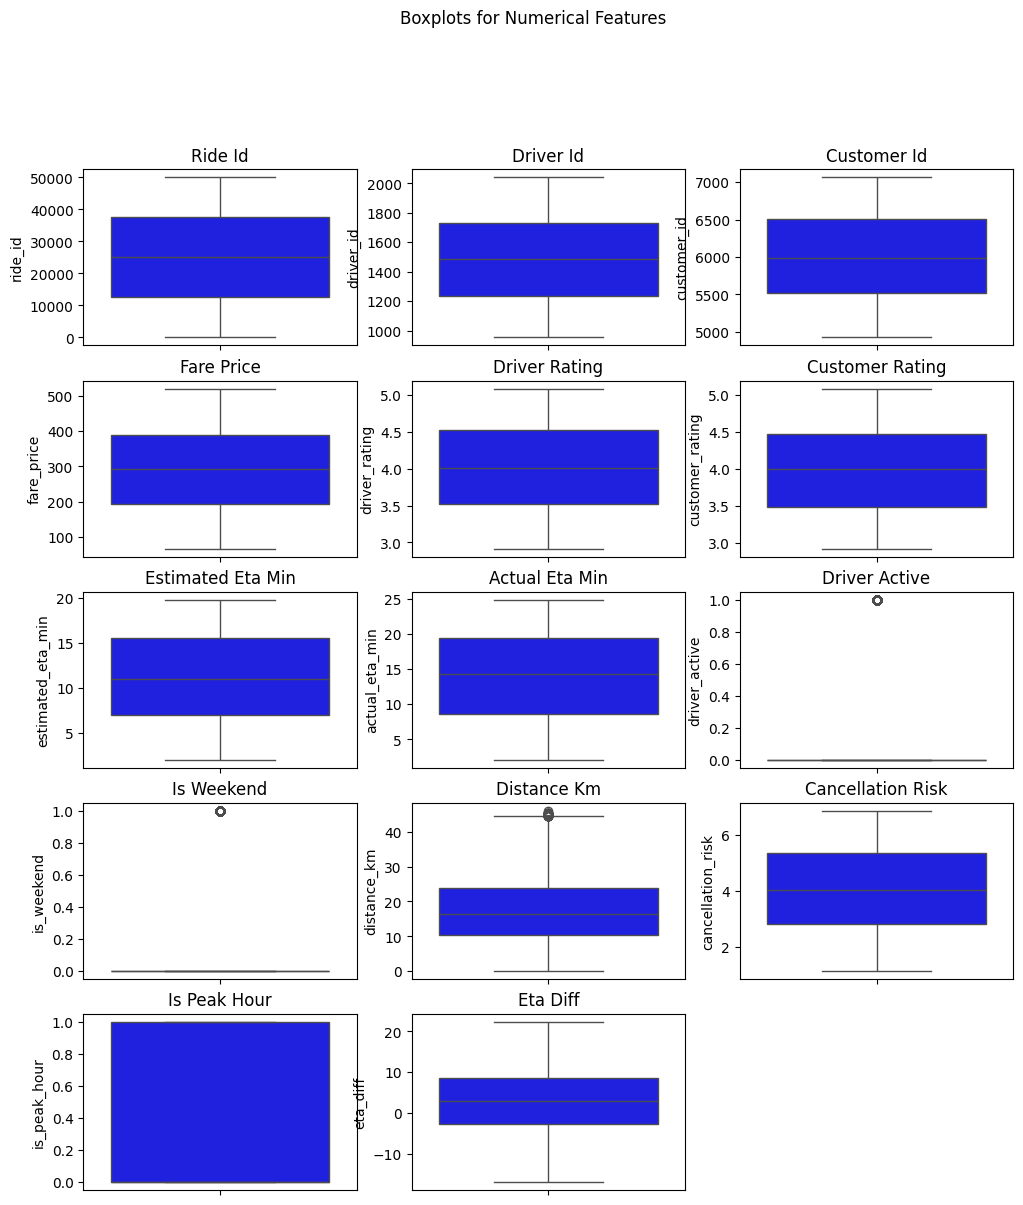

In [25]:
#box plot for numerical features
plt.figure(figsize=(12,16))
plt.suptitle("Boxplots for Numerical Features")
for i, feature in enumerate(numerical_features):
    plt.subplot(6, 3, i+1)
    sns.boxplot(y=original_data[feature],color='blue')
    plt.title(feature.replace("_", " ").title())


In [26]:
#check for skewness in numerical features
skewness = original_data[numerical_features].skew()
print(skewness)

ride_id              0.000000
driver_id            0.063728
customer_id         -0.011622
fare_price          -0.048710
driver_rating       -0.029831
customer_rating     -0.000363
estimated_eta_min   -0.044094
actual_eta_min      -0.093535
driver_active        1.173198
is_weekend           1.291012
distance_km          0.512603
cancellation_risk   -0.054754
is_peak_hour         1.150676
eta_diff            -0.061150
dtype: float64


Insights of Outliers and Distribution
Most of the features show very slight skewness, but fall under acceptable range -1 to 1.  
Surge multiplier and distance_km reflect real-world variability
Binary features do not require outlier handling - driver_active, is_weekend, is_peak_hour. 

Univariate - Distribution analysis of few important features

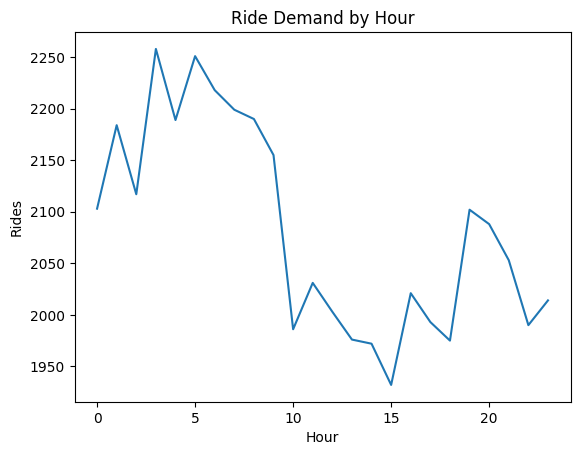

In [27]:
#ride demand by hour 
# hour is a key feature for demand prediction and 
# also shows a clear pattern in the data with peaks during morning and evening rush hours. 
# This insight can be crucial for model building and feature engineering.
original_data.groupby('hour').size().plot(kind='line')
plt.title("Ride Demand by Hour")
plt.xlabel("Hour")
plt.ylabel("Rides")
plt.show()

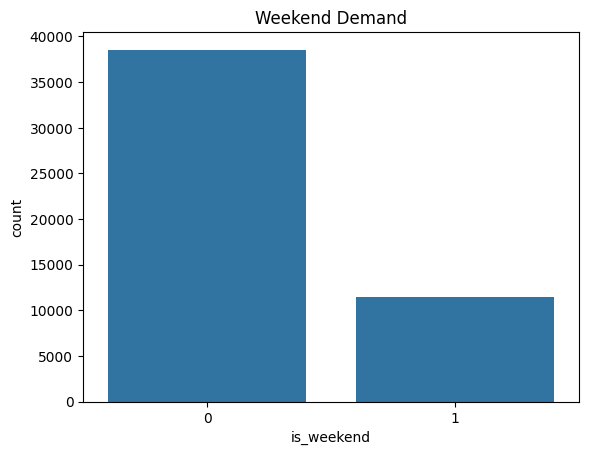

In [28]:
#weekend vs weekday demand
sns.countplot(x='is_weekend', data=original_data)
plt.title("Weekend Demand")
plt.show()

Text(0.5, 1.0, 'Distance Distribution')

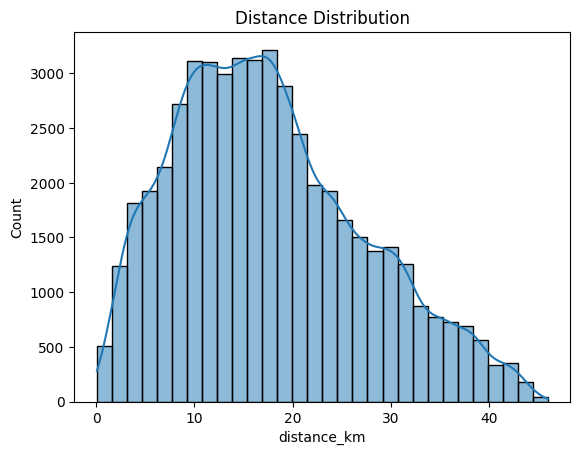

In [29]:
#distance distribution
sns.histplot(original_data['distance_km'], bins=30, kde=True)
plt.title("Distance Distribution")

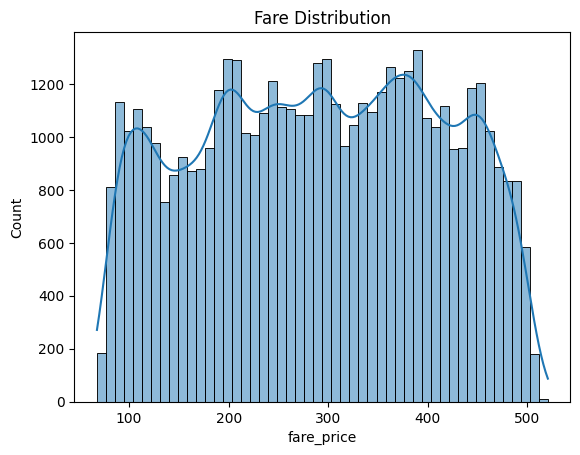

In [30]:
#fare distribution
sns.histplot(original_data['fare_price'], bins=50, kde=True)
plt.title("Fare Distribution")
plt.show()

<Axes: xlabel='fare_price', ylabel='ride_count'>

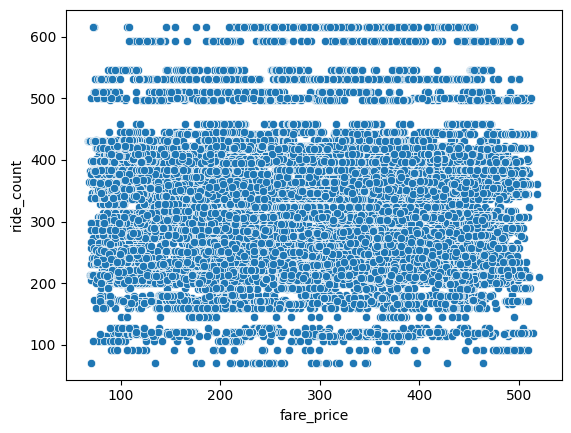

In [50]:
#bivariare analysis
#Fare price vs ride count
sns.scatterplot(x='fare_price', y='ride_count', data=original_data)

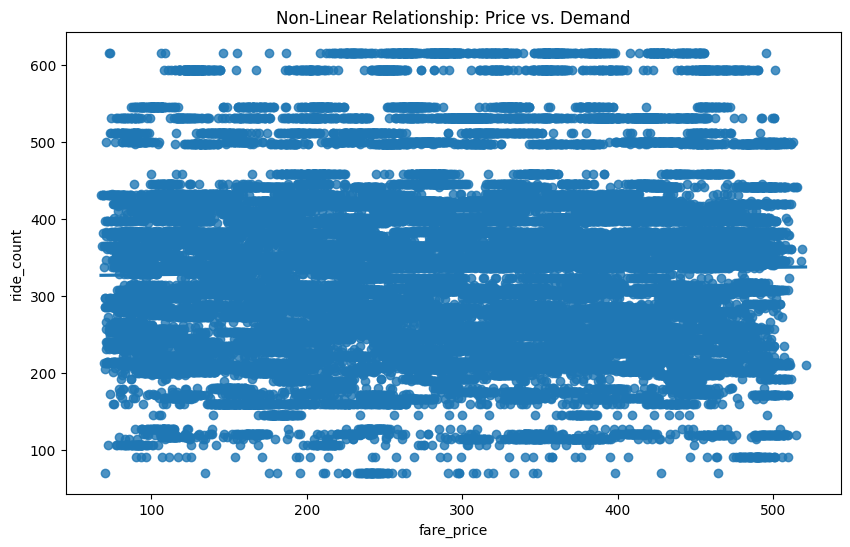

In [55]:
# Check for non-linear price sensitivity
plt.figure(figsize=(10, 6))
sns.regplot(data=original_data, x='fare_price', y='ride_count')
plt.title("Non-Linear Relationship: Price vs. Demand")
plt.show()

In [31]:
numerical_features = original_data.select_dtypes(include=['float64', 'int64']).columns
numerical_features = numerical_features.drop(targets)
print(numerical_features)

Index(['ride_id', 'driver_id', 'customer_id', 'fare_price', 'driver_rating',
       'customer_rating', 'estimated_eta_min', 'actual_eta_min',
       'driver_active', 'is_weekend', 'distance_km', 'cancellation_risk',
       'is_peak_hour', 'eta_diff'],
      dtype='object')


In [32]:
check_features =  ['fare_price', 'driver_rating',
       'customer_rating', 'estimated_eta_min', 'actual_eta_min',
       'driver_active', 'is_weekend', 'distance_km', 'cancellation_risk',
       'is_peak_hour', 'eta_diff']

In [33]:
targets

['ride_count', 'available_drivers', 'surge_multiplier', 'ride_status']

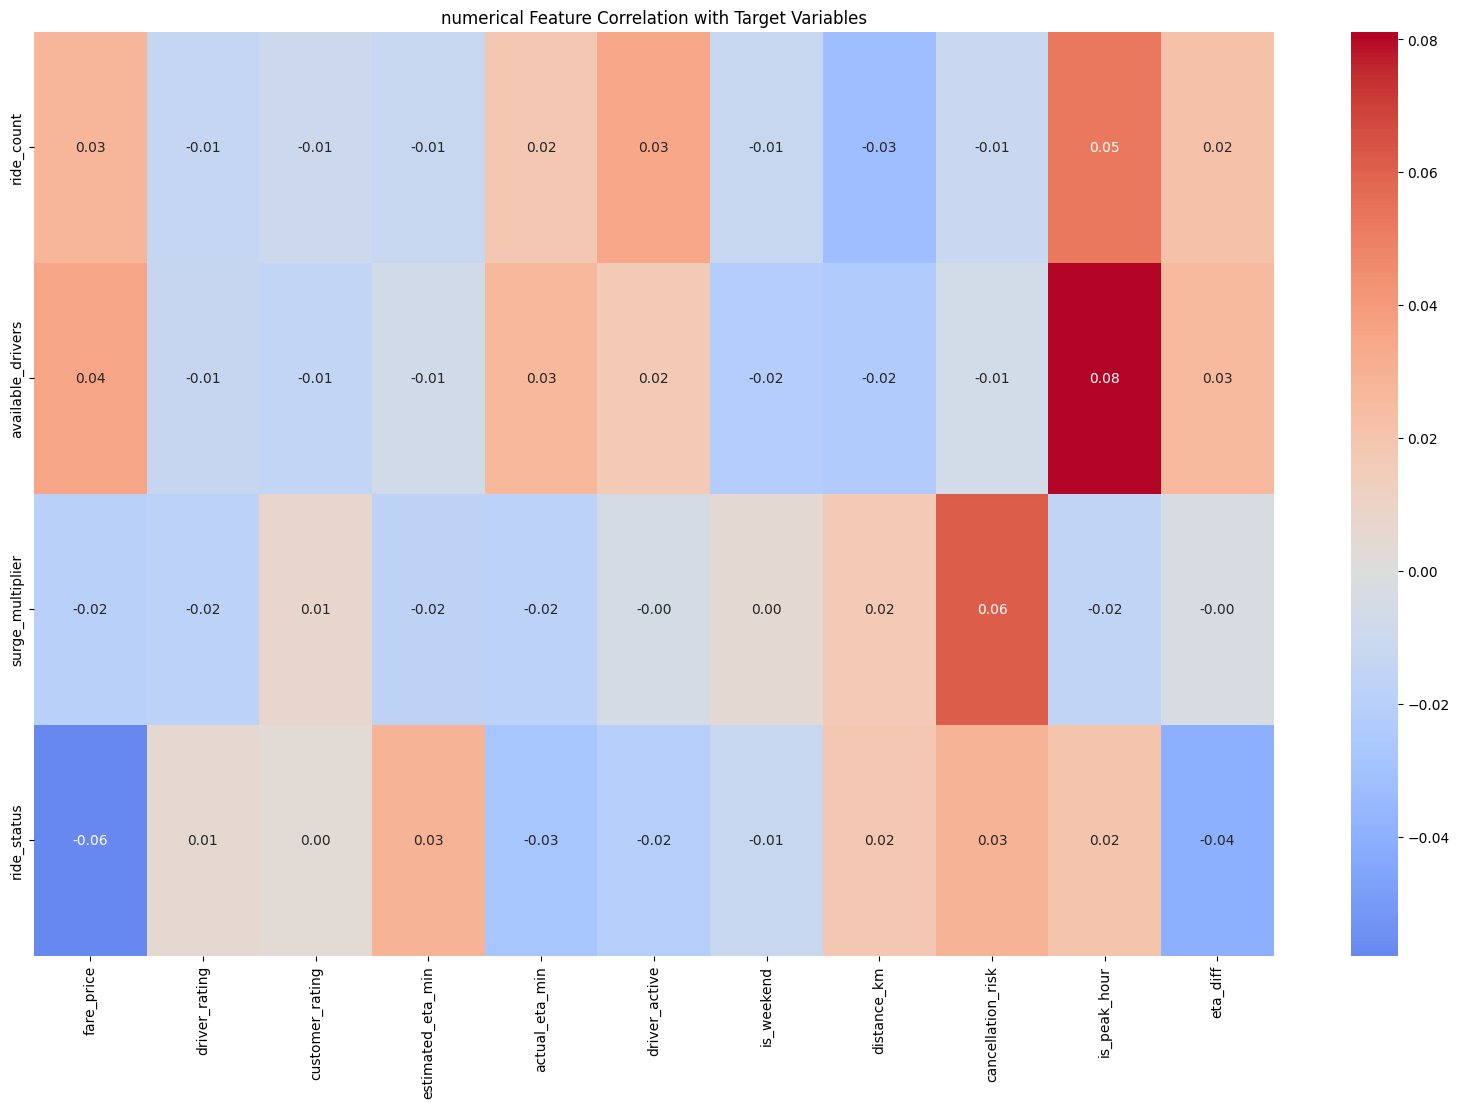

In [34]:
#correlation matrix

corr_matrix = original_data[targets + check_features].corr()
subset_corr = corr_matrix.loc[targets, check_features]
plt.figure(figsize=(20, 12))
sns.heatmap(subset_corr, 
            annot=True,       # Show the correlation numbers
            fmt=".2f",        # Format to 2 decimal places
            cmap='coolwarm',  # Red for positive, Blue for negative correlation
            center=0)         # Set 0 as the neutral color (white/gray)

plt.title("numerical Feature Correlation with Target Variables")
plt.show()
plt.clf()      # clear current figure
plt.close('all')

Correlation insights:
No strong correlation seen, conveying that the problem is non linear. 
is_peak_hour, fare_price, driver_active, hour, cancellation risk, eta_diff are high important features
ride_status and surge_multiplier has no linear relationship with any of the numerical features. 

Categorical columns distribution

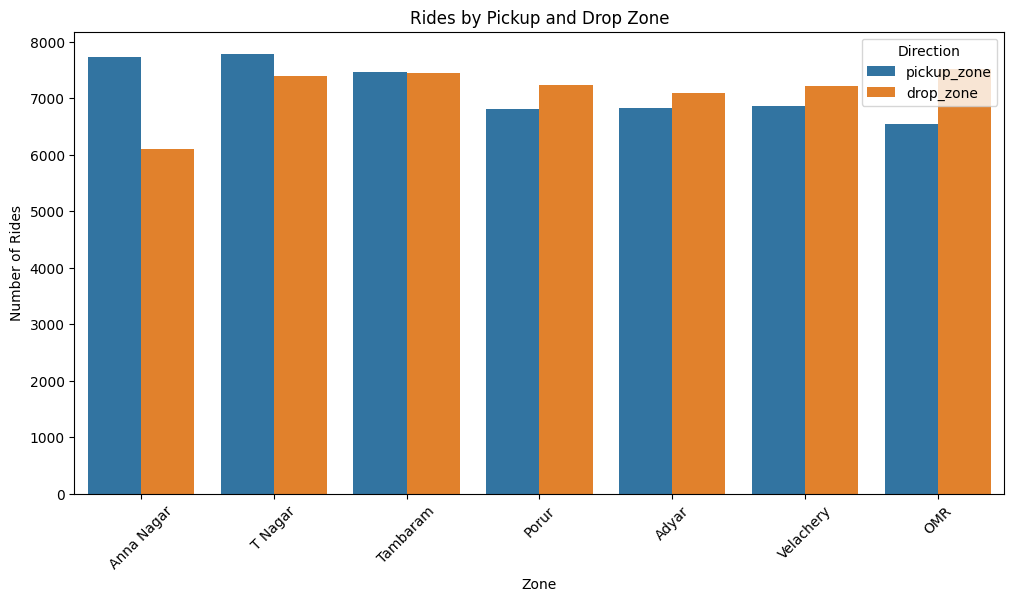

In [35]:
#pickup zone distribution & #dropzone distribution  combined view bars
# grouped bar plot
# 1. Melt the data so Pickup and Drop zones are in one column
plot_data = original_data.melt(value_vars=['pickup_zone', 'drop_zone'], 
                               var_name='Zone Type', 
                               value_name='Zone Name')

# 2. Create the plot
plt.figure(figsize=(12, 6))
sns.countplot(data=plot_data, x='Zone Name', hue='Zone Type')

# 3. Add styling
plt.title("Rides by Pickup and Drop Zone")
plt.xlabel("Zone")
plt.ylabel("Number of Rides")
plt.xticks(rotation=45) # Helps if zone names are long
plt.legend(title="Direction")
plt.show()

<Axes: xlabel='weather', ylabel='count'>

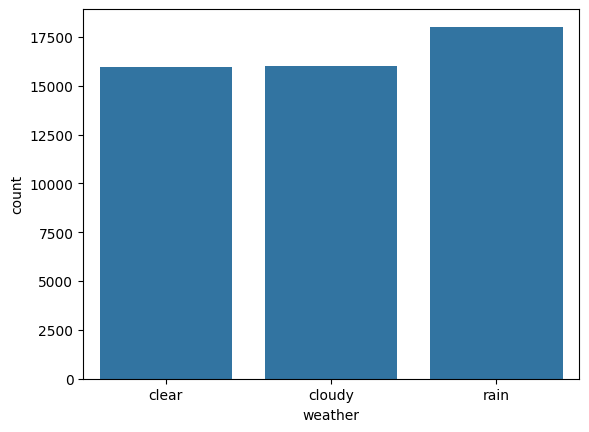

In [36]:
#weather condition distribution
sns.countplot(x='weather', data=original_data)

<Axes: xlabel='traffic_level', ylabel='count'>

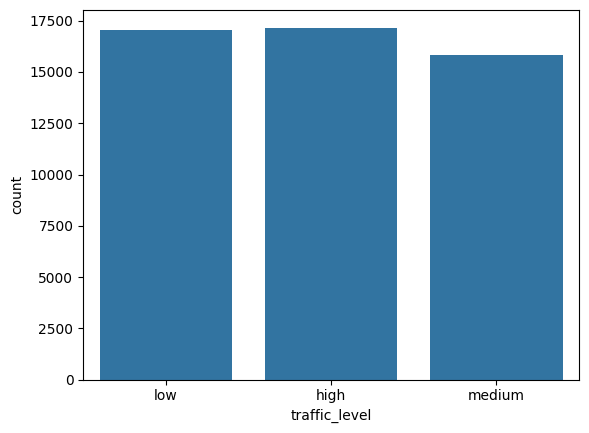

In [37]:
#traffic level distribution
sns.countplot(x='traffic_level', data=original_data)    


Encoding

In [38]:
#Encoding pickup_zone, drop_zone and weather using one-hot encoding
original_data = pd.get_dummies(
    original_data,
    columns=['pickup_zone', 'drop_zone', 'weather'],
    dtype=int
)

In [39]:
#encoding traffic_level using label encoding since it has an inherent order (low < medium < high)
original_data['traffic_level'] = original_data['traffic_level'].map({
    'low': 0,
    'medium': 1,
    'high': 2
})

In [40]:
original_data.columns

Index(['ride_id', 'driver_id', 'customer_id', 'fare_price', 'surge_multiplier',
       'driver_rating', 'customer_rating', 'estimated_eta_min',
       'actual_eta_min', 'ride_status', 'traffic_level', 'driver_active',
       'feedback_text', 'hour', 'day_of_week', 'is_weekend',
       'available_drivers', 'distance_km', 'cancellation_risk', 'is_peak_hour',
       'eta_diff', 'ride_count', 'pickup_zone_Adyar', 'pickup_zone_Anna Nagar',
       'pickup_zone_OMR', 'pickup_zone_Porur', 'pickup_zone_T Nagar',
       'pickup_zone_Tambaram', 'pickup_zone_Velachery', 'drop_zone_Adyar',
       'drop_zone_Anna Nagar', 'drop_zone_OMR', 'drop_zone_Porur',
       'drop_zone_T Nagar', 'drop_zone_Tambaram', 'drop_zone_Velachery',
       'weather_clear', 'weather_cloudy', 'weather_rain'],
      dtype='object')

In [47]:
encoded_columns = ['pickup_zone_Adyar', 'pickup_zone_Anna Nagar',
       'pickup_zone_OMR', 'pickup_zone_Porur', 'pickup_zone_T Nagar',
       'pickup_zone_Tambaram', 'pickup_zone_Velachery', 'drop_zone_Adyar',
       'drop_zone_Anna Nagar', 'drop_zone_OMR', 'drop_zone_Porur',
       'drop_zone_T Nagar', 'drop_zone_Tambaram', 'drop_zone_Velachery',
       'weather_clear', 'weather_cloudy', 'weather_rain', 'traffic_level']

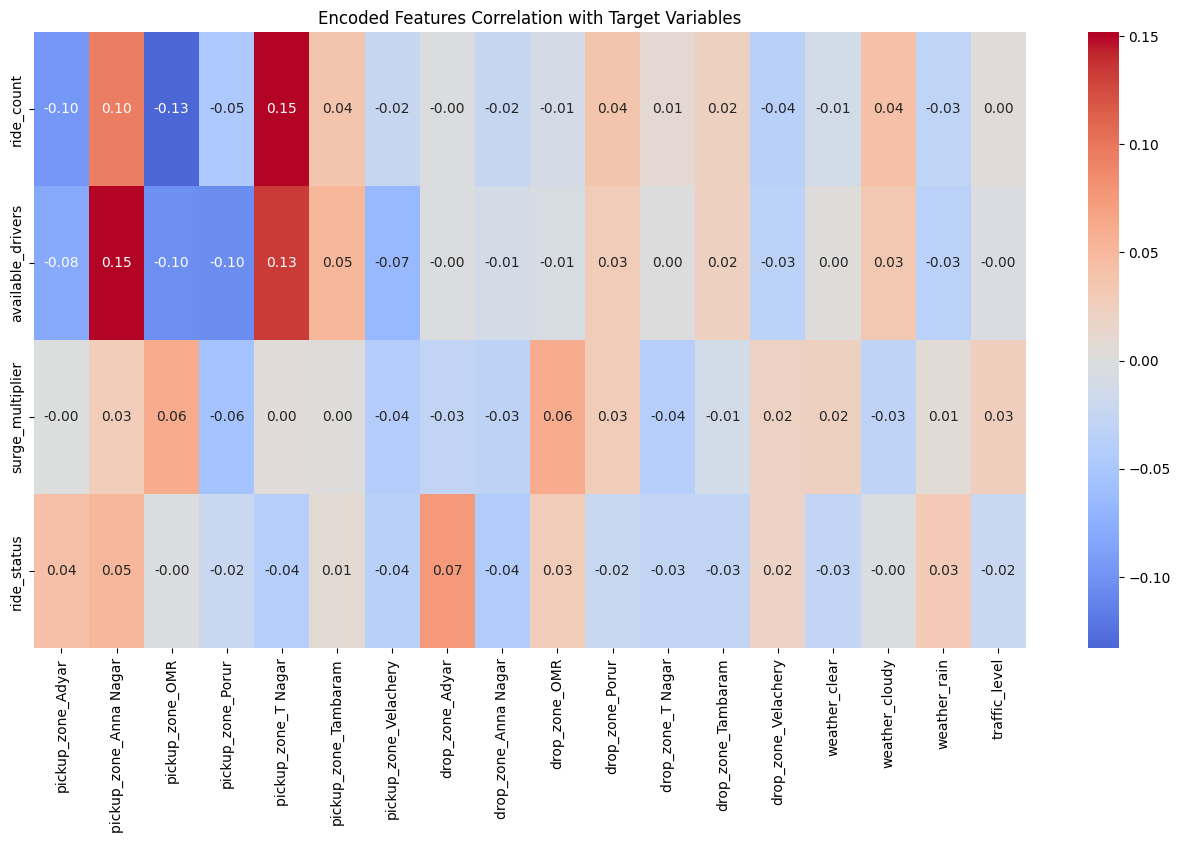

In [48]:
plt.close('all')
#correlation matrix for encoded features
corr_matrix = original_data[targets + encoded_columns].corr()
results=  corr_matrix.loc[targets, encoded_columns]
plt.figure(figsize=(16, 8))
sns.heatmap(results, 
            annot=True,       # Show the correlation numbers
            fmt=".2f",        # Format to 2 decimal places
            cmap='coolwarm',  # Red for positive, Blue for negative correlation
            center=0)         # Set 0 as the neutral color (white/gray)

plt.title("Encoded Features Correlation with Target Variables")
plt.show()
plt.clf()      # clear current figure
plt.close('all')

#insights
Pickup zones and drop zones of few areas like Anna Nagar, T nagar, OMR are slightly correlated with Targets. Slight impact with Weather and Traffic level. Thus these features might improve the prediction and respond as important features.
Although the correlation between features are too weak, the combined effect might give good results. 

In [56]:
#saving the preprocessed dataset for future use
original_data.to_csv(r"C:\Users\chaka\Preethu\My_Git_Repo\Final Project_Rideflow\Datasets\preprocessed_rideflow_datasets.csv", index=False)